# Goal

Get the Lasair API to work and get all alerts coming from nearby galaxies. We are using Lasair's built-in Sherlock system to do host galaxy association.



Some useful links:   

API client: https://lasair-lsst.readthedocs.io/en/main/core_functions/client.html    
Example notebooks: https://github.com/lsst-uk/lasair-examples/tree/main/lsst_notebooks  
Specifically for notebooks: https://github.com/lsst-uk/lasair-examples/tree/main/lsst_notebooks/api  
Lasair LSST schema browser: https://lasair.lsst.ac.uk/schema/#objects_ext-schema  

Example to get fits cutouts: https://community.lsst.org/t/does-lasair-provide-and-store-cutouts-for-all-alerts-including-past-ones/11002  
Also see: https://community.lsst.org/t/invalid-cutout-fits-files/11626/4  
NOTE: They only seem to be stored for a month?

## Imports and settings

In [1]:
from lasair import LasairError, lasair_client as lasair
import json
import os 
import wget
import numpy as np
from astropy.io import fits
from astropy.time import Time
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

In [2]:
# Connect to the Lasair API 
import settings # This is where you should place your API_TOKEN
endpoint = "https://api.lasair.lsst.ac.uk/api"
L = lasair(settings.API_TOKEN, endpoint=endpoint)

## Code

In [3]:
# The query...

selected = '''
        objects.diaObjectId,
       objects.ra,
       objects.decl,
       mjdnow()-objects.lastDiaSourceMjdTai AS since,
       objects.lastDiaSourceMjdTai,
       objects.latestR,
       objects.nDiaSources,
       sherlock_classifications.classification,
       sherlock_classifications.association_type,
       sherlock_classifications.distance,
       sherlock_classifications.z,
       sherlock_classifications.classificationReliability,
       sherlock_classifications.major_axis_arcsec,
       sherlock_classifications.separationArcsec,
       sherlock_classifications.physical_separation_kpc
'''

tables = 'objects,sherlock_classifications'

conditions = '''
objects.diaObjectId=sherlock_classifications.diaObjectId AND sherlock_classifications.classification IN ("SN", "NT") AND
mjdnow()  - objects.lastDiaSourceMjdTai <= 50 AND 
(sherlock_classifications.distance < 130 or sherlock_classifications.direct_distance <130 or sherlock_classifications.z <  0.03) AND 
sherlock_classifications.physical_separation_kpc < 20
'''

results = L.query(selected, tables, conditions, limit = 8) 
results = pd.DataFrame(results)
results.head()

,diaObjectId,ra,decl,since,lastDiaSourceMjdTai,latestR,nDiaSources,classification,association_type,distance,z,classificationReliability,major_axis_arcsec,separationArcsec,physical_separation_kpc
0,170019696300523640,60.151232,-49.046520,26.713336,61105.093204,0.807440,192,SN,SN,None,0.003532,2,None,90.462,6.606
1,170019696300523661,60.181632,-48.993190,41.712050,61090.094489,0.109701,2,SN,SN,None,0.003532,2,None,192.152,14.033
2,170019696304193611,59.426619,-48.908000,36.745887,61095.060653,0.369244,15,SN,SN,None,0.003766,2,None,1.926,0.150
3,170019696348758106,57.279366,-48.858137,37.700581,61094.105958,0.316431,4,SN,SN,None,0.003269,2,None,6.849,0.621
4,170019696393848492,65.265153,-48.303625,36.721471,61095.085069,0.379674,21,SN,SN,None,0.015614,2,None,1.621,0.516


In [4]:
# Get the images associated with one of these alerts
diaObjectId = results['diaObjectId'][0]

# Query Lasair again for that specific diaobjectid
objResult = L.object(diaObjectId, lasair_added=True)

In [5]:
objResult

{'diaObjectId': '170019696300523640',
 'lasairData': {'nDiaSources': 192,
  'firstDiaSourceMjdTai': 61088.098045202045,
  'lastDiaSourceMjdTai': 61105.09320382924,
  'glat': -47.7346,
  'ebv': 0.00827398,
  'rasex': '04:00:36.296',
  'decsex': '-49:02:47.474',
  'ec_lon': 34.13573231640091,
  'ec_lat': -66.78842034003011,
  'g_lon': 257.197502300872,
  'g_lat': -47.734559934696215,
  'now_mjd': '61131.81',
  'mjdmin_ago': 43.70871336998971,
  'mjdmax_ago': 26.713554742796987,
  'discMjd': 61088.098045202045,
  'discUtc': '2026-02-17 02:21:11',
  'discMag': '939.05±151.82',
  'discFilter': 'r',
  'latestMjd': 61105.09320382924,
  'latestUtc': '2026-03-06 02:14:12',
  'latestMag': '3276.23±432.59',
  'latestFilter': 'r',
  'peakMjd': 61105.09320382924,
  'peakUtc': '2026-03-06 02:14:12',
  'peakMag': '3276.23±432.59',
  'peakFilter': 'i',
  'sherlock': {'diaObjectId': 170019696300523640,
   'classification': 'SN',
   'association_type': 'SN',
   'catalogue_table_name': 'LASR',
   'catalo

In [6]:
# Download the images with wget


# Get the image urls
urls = objResult['lasairData']['imageUrls']

# Use the latest epoch
idx = np.argmax([objResult['diaSourcesList'][i]['midpointMjdTai'] for i in range(len(objResult['diaSourcesList']))])
science_url = urls[idx]['Science']#+'.fits'
out_path = 'data/temp'+'.fits'

# Remove file if it already exists
if os.path.exists(out_path):
    os.remove(out_path)

wget.download(science_url, out=out_path)

'data/temp.fits'

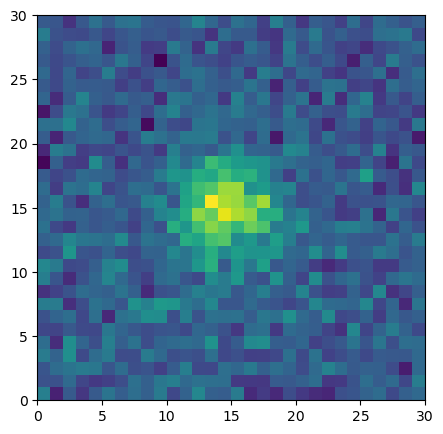

In [7]:
# Open and plot fits file

ff = fits.open(out_path)
plt.figure(figsize = (5,5))
plt.pcolormesh(ff[0].data)
plt.show()

In [8]:
# Get sherlock information about that diaobject

lite=False
sherlock_result = L.sherlock_object(diaObjectId, lite=lite)
sherlock_result

{'classifications': {'170019696300523640': ['SN',
   'The transient is possibly associated with <em>ESO201-G014</em>; a W1=11.92 mag galaxy found in the LASR catalogue. It\'s located 60.00" S, 67.80" E (6.6 Kpc) from the galaxy centre. A host z=0.004 implies a <em>m - M =</em> 30.90.']},
 'crossmatches': [{'W1': 11.918,
   'W1Err': 0.023,
   'association_type': 'SN',
   'best_distance': 15.169934110367915,
   'best_distance_flag': 'sz',
   'best_distance_source': 'LASr 100 Mpc Galaxy Catalogue v1.0',
   'catalogue_object_id': 'ESO201-G014',
   'catalogue_object_subtype': 0,
   'catalogue_object_type': 'galaxy',
   'catalogue_table_id': 81,
   'catalogue_table_name': 'LASR',
   'catalogue_view_id': 51,
   'catalogue_view_name': 'tcs_view_galaxy_lasr_v1',
   'classificationReliability': 2,
   'decDeg': -49.02986,
   'direct_distance': None,
   'direct_distance_cat': 'LASr 100 Mpc Galaxy Catalogue v1.0',
   'direct_distance_modulus': None,
   'direct_distance_scale': None,
   'eastSeparat